In [1]:
import yfinance as yf
import pandas as pd
import plotly.express as px
import numpy as np

In [2]:
# settings 
symbol = 'GC=F'
timeframe = '1h'
num_days = '60d'
start_pos = 0

fsma_period = 10
ssma_period = 100

In [3]:
# import gold future daily market data 
df = yf.download("GC=F", period="60d", interval="1h")
df.columns = [col[0] for col in df.columns]
df = df[["Open", "High", "Low", "Close"]]
df = df.reset_index()
print(df.columns)

# adding slow and fast moving average
df['slow_sma'] = df ['Close'].rolling(ssma_period).mean()
df['fast_sma'] = df ['Close'].rolling(fsma_period).mean()

# adding prev fast moving average
df['prev_fast_sma'] = df['fast_sma'].shift(1)

# dropping na values
df.dropna(inplace=True)
df

[*********************100%***********************]  1 of 1 completed

Index(['Datetime', 'Open', 'High', 'Low', 'Close'], dtype='object')


,Datetime,Open,High,Low,Close,slow_sma,fast_sma,prev_fast_sma
99,2026-02-27 06:00:00+00:00,5214.600098,5216.299805,5201.899902,5202.799805,5196.473003,5203.720020,5203.860059
100,2026-02-27 07:00:00+00:00,5202.899902,5206.500000,5192.600098,5193.100098,5196.532002,5201.680029,5203.720020
101,2026-02-27 08:00:00+00:00,5193.200195,5199.399902,5191.100098,5195.100098,5196.824004,5201.040039,5201.680029
102,2026-02-27 09:00:00+00:00,5195.399902,5199.299805,5188.500000,5192.299805,5196.953003,5200.180029,5201.040039
103,2026-02-27 10:00:00+00:00,5192.500000,5197.200195,5183.200195,5193.600098,5196.939004,5200.380029,5200.180029
...,...,...,...,...,...,...,...,...
1116,2026-05-01 16:00:00+00:00,4654.000000,4661.299805,4644.899902,4650.600098,4622.720034,4609.950000,4605.569971
1117,2026-05-01 17:00:00+00:00,4650.200195,4654.500000,4638.399902,4641.299805,4621.942031,4615.129980,4609.950000
1118,2026-05-01 18:00:00+00:00,4641.700195,4642.799805,4625.299805,4636.100098,4621.060034,4620.710010,4615.129980
1119,2026-05-01 19:00:00+00:00,4636.200195,4639.600098,4621.000000,4623.000000,4620.093032,4625.650000,4620.710010


In [4]:
# finding crossovers
def find_crossover(fast_sma, prev_fast_sma, slow_sma):
    if fast_sma > slow_sma and prev_fast_sma < slow_sma:
        return 'bullish crossover'
    elif fast_sma < slow_sma and prev_fast_sma > slow_sma:
        return 'bearish crossover'

    return None
    
df['crossover'] = np.vectorize(find_crossover)(df['fast_sma'], df['prev_fast_sma'], df['slow_sma'])

# finding all identified bullish crossovers
signal = df[df['crossover'] == 'bullish crossover'].copy()
signal

,Datetime,Open,High,Low,Close,slow_sma,fast_sma,prev_fast_sma,crossover
256,2026-03-10 01:00:00+00:00,5140.299805,5195.200195,5134.000000,5193.200195,5137.133013,5140.420068,5131.360059,bullish crossover
513,2026-03-25 05:00:00+00:00,4571.100098,4572.000000,4546.700195,4555.000000,4532.718989,4534.670020,4518.260010,bullish crossover
564,2026-03-27 10:00:00+00:00,4457.200195,4461.000000,4438.600098,4442.799805,4442.120986,4444.020020,4437.140039,bullish crossover
713,2026-04-07 22:00:00+00:00,4747.200195,4847.100098,4740.500000,4845.100098,4703.803008,4706.239990,4690.189990,bullish crossover
810,2026-04-14 03:00:00+00:00,4797.700195,4797.799805,4787.899902,4792.299805,4775.745005,4778.050000,4774.460010,bullish crossover
887,2026-04-17 11:00:00+00:00,4809.200195,4834.000000,4805.500000,4822.000000,4812.259009,4813.080029,4811.900049,bullish crossover
888,2026-04-17 12:00:00+00:00,4821.700195,4870.799805,4819.799805,4869.000000,4813.502007,4819.520020,4813.080029,bullish crossover
915,2026-04-20 23:00:00+00:00,4848.700195,4852.500000,4840.500000,4842.399902,4833.216006,4833.779932,4831.869922,bullish crossover


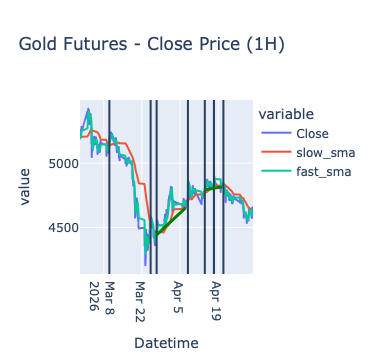

In [12]:
# visulizing 1hr close price
fig = px.line(df, x="Datetime", y=["Close", 'slow_sma', 'fast_sma'], title="Gold Futures - Close Price (1H)")

# visualsing all identified buy signals (bullish crossovers)
for i, row in signal.iterrows():
    fig.add_vline(x=row.Datetime)

for i, row in result[result['status'] == 'closed'].iterrows():

    if row.profit > 0:
        fig.add_shape(type="line",
                      x0=row.open_datetime, y0=row.open_price, x1=row.close_datetime, y1=row.close_price,
                      line=dict(color="Green",width=3))

fig.show()

In [7]:
# creating position classes
class Position:
    def __init__(self, open_datetime, open_price, order_type, volume, sl, tp):
        self.open_datetime = open_datetime
        self.open_price = open_price
        self.order_type = order_type
        self.volume = volume
        self.sl = sl
        self.tp = tp
        self.close_datetime = None
        self.close_price = None
        self.profit = None
        self.status = 'open'

    def close_position(self, close_datetime, close_price):
        self.close_datetime = close_datetime
        self.close_price = close_price
        self.profit = (self.close_price - self.open_price) * self.volume if self.order_type == 'buy' \
                                                                        else (self.open_price - self.close_price) * self.volume
        self.status = 'closed'

    def _asdict(self):
        return {
            'open_datetime': self.open_datetime,
            'open_price': self.open_price,
            'order_type': self.order_type,
            'volume': self.volume,
            'sl': self.sl,
            'tp': self.tp,
            'close_datetime': self.close_datetime,
            'close_price': self.close_price,
            'profit': self.profit,
            'status': self.status,
        }

class stratagey:
    def __init__(self, df, starting_balance, volume):
        self.starting_balance = starting_balance
        self.volume = volume 
        self.positions = []
        self.data = df
    def get_positions_df(self):
        df = pd.DataFrame([position._asdict() for position in self.positions])
        df['pnl'] = df['profit'].cumsum() + self.starting_balance
        return df

    def add_position(self, position):
        self.positions.append(position)

        return True

# logic
    def run(self):
        for i, data in self.data.iterrows():
            
            if data.crossover == 'bearish crossover':
                for p in self.positions:
                    if p.status == 'open':
                        p.close_position(data.Datetime, data.Close)
        
            if data.crossover == 'bullish crossover':
                self.add_position(Position(data.Datetime, data.Close, 'buy', self.volume, 0, 0))

        return self.get_positions_df()     

# run
sma_crossover_stratagey = stratagey(df, 10000, 1)
result = sma_crossover_stratagey.run()
result

,open_datetime,open_price,order_type,volume,sl,tp,close_datetime,close_price,profit,status,pnl
0,2026-03-10 01:00:00+00:00,5193.200195,buy,1,0,0,2026-03-12 18:00:00+00:00,5100.000000,-93.200195,closed,9906.799805
1,2026-03-25 05:00:00+00:00,4555.000000,buy,1,0,0,2026-03-26 09:00:00+00:00,4421.299805,-133.700195,closed,9773.099609
2,2026-03-27 10:00:00+00:00,4442.799805,buy,1,0,0,2026-04-07 01:00:00+00:00,4651.899902,209.100098,closed,9982.199707
3,2026-04-07 22:00:00+00:00,4845.100098,buy,1,0,0,2026-04-13 01:00:00+00:00,4743.100098,-102.000000,closed,9880.199707
4,2026-04-14 03:00:00+00:00,4792.299805,buy,1,0,0,2026-04-20 10:00:00+00:00,4815.700195,23.400391,closed,9903.600098
5,2026-04-17 11:00:00+00:00,4822.000000,buy,1,0,0,2026-04-20 10:00:00+00:00,4815.700195,-6.299805,closed,9897.300293
6,2026-04-17 12:00:00+00:00,4869.000000,buy,1,0,0,2026-04-20 10:00:00+00:00,4815.700195,-53.299805,closed,9844.000488
7,2026-04-20 23:00:00+00:00,4842.399902,buy,1,0,0,2026-04-21 03:00:00+00:00,4816.299805,-26.100098,closed,9817.900391


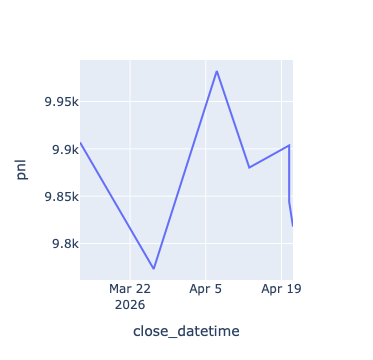

In [9]:
px.line(result, x='close_datetime', y='pnl')